In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter


> ## Part 1
>
> 1. **Load in the Zillow Home Value Index dataframe**
>    - Note: it is a large file and may take a minute to load
>
> 2. **Filter the 4 largest cities into a new dataframe**
>    - Tip: the `SizeRank` column has already ranked the cities by size
>    - The larger the city, the smaller the rank value
>    - Therefore the 4 largest cities would have rank values of `[0, 1, 2, 3]`
>
> 3. **Melt the data to long-form and prepare it for time series analysis**
>    - Convert the melted dates into `datetime` datatype
>    - Make the datetime column the index
>
> 4. **Resample the dataframe at monthly frequency, grouped by City**

In [59]:
# 1. Load in the Zillow Home Value Index dataframe
# load and check the dataset
df = pd.read_csv('zillow-home-analysis.csv')

# run the head
df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,Metro,CountyName,2000-01-31,2000-02-29,...,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31,2026-04-30,2026-05-31
0,6181,0,New York,city,NY,NY,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,240543.592002,241823.720814,...,788722.182626,790761.938548,794310.149148,798157.535397,801287.722548,804731.423092,809721.417474,814827.637729,817470.616545,817744.531151
1,12447,1,Los Angeles,city,CA,CA,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,224723.963733,225064.220279,...,950207.781249,952390.801416,955385.601555,958962.781245,962687.810453,963919.512365,962738.771664,958968.139935,954655.051793,951034.767271
2,39051,2,Houston,city,TX,TX,"Houston-The Woodlands-Sugar Land, TX",Harris County,104967.981691,104941.312087,...,269193.149983,268497.231731,267915.477537,267632.682397,267682.123946,267621.300126,267308.755163,266697.043589,265925.840435,264951.507798
3,17426,3,Chicago,city,IL,IL,"Chicago-Naperville-Elgin, IL-IN-WI",Cook County,150008.582202,150048.659977,...,315356.420691,316388.505150,317597.134759,318896.611991,320060.338523,321051.512214,322480.365442,323843.857744,325076.354628,325887.336287
4,6915,4,San Antonio,city,TX,TX,"San Antonio-New Braunfels, TX",Bexar County,101261.809291,101355.819240,...,254451.238789,254179.640331,253782.432289,253400.135839,253108.306133,252808.189935,252568.690663,252276.689533,251837.226672,251064.622912


In [60]:
# 2. Filter the 4 largest cities into a new dataframe
largest_cities = df[df['SizeRank'].isin([0, 1, 2, 3])]
largest_cities

,RegionID,SizeRank,RegionName,RegionType,StateName,State,Metro,CountyName,2000-01-31,2000-02-29,...,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31,2026-04-30,2026-05-31
0,6181,0,New York,city,NY,NY,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,240543.592002,241823.720814,...,788722.182626,790761.938548,794310.149148,798157.535397,801287.722548,804731.423092,809721.417474,814827.637729,817470.616545,817744.531151
1,12447,1,Los Angeles,city,CA,CA,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,224723.963733,225064.220279,...,950207.781249,952390.801416,955385.601555,958962.781245,962687.810453,963919.512365,962738.771664,958968.139935,954655.051793,951034.767271
2,39051,2,Houston,city,TX,TX,"Houston-The Woodlands-Sugar Land, TX",Harris County,104967.981691,104941.312087,...,269193.149983,268497.231731,267915.477537,267632.682397,267682.123946,267621.300126,267308.755163,266697.043589,265925.840435,264951.507798
3,17426,3,Chicago,city,IL,IL,"Chicago-Naperville-Elgin, IL-IN-WI",Cook County,150008.582202,150048.659977,...,315356.420691,316388.505150,317597.134759,318896.611991,320060.338523,321051.512214,322480.365442,323843.857744,325076.354628,325887.336287


In [61]:
# 3) a. Melt the data to long-form and prepare it for time series analysis
largest_cities_long = largest_cities_long = largest_cities.drop(columns=['RegionID']).melt(
    id_vars=['SizeRank', 'RegionName', 'RegionType', 'StateName', 'State', 'Metro', 'CountyName'],
    var_name='Date',
    value_name='HomeValue'
)
largest_cities_long

,SizeRank,RegionName,RegionType,StateName,State,Metro,CountyName,Date,HomeValue
0,0,New York,city,NY,NY,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,2000-01-31,240543.592002
1,1,Los Angeles,city,CA,CA,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,2000-01-31,224723.963733
2,2,Houston,city,TX,TX,"Houston-The Woodlands-Sugar Land, TX",Harris County,2000-01-31,104967.981691
3,3,Chicago,city,IL,IL,"Chicago-Naperville-Elgin, IL-IN-WI",Cook County,2000-01-31,150008.582202
4,0,New York,city,NY,NY,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,2000-02-29,241823.720814
...,...,...,...,...,...,...,...,...,...
1263,3,Chicago,city,IL,IL,"Chicago-Naperville-Elgin, IL-IN-WI",Cook County,2026-04-30,325076.354628
1264,0,New York,city,NY,NY,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,2026-05-31,817744.531151
1265,1,Los Angeles,city,CA,CA,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,2026-05-31,951034.767271
1266,2,Houston,city,TX,TX,"Houston-The Woodlands-Sugar Land, TX",Harris County,2026-05-31,264951.507798


In [62]:
# 3) b. Make the datetime column the index
largest_cities_long['Date'] = pd.to_datetime(largest_cities_long['Date'])
largest_cities_long.set_index('Date', inplace=True)
largest_cities_long

,SizeRank,RegionName,RegionType,StateName,State,Metro,CountyName,HomeValue
Date,,,,,,,,
2000-01-31,0,New York,city,NY,NY,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,240543.592002
2000-01-31,1,Los Angeles,city,CA,CA,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,224723.963733
2000-01-31,2,Houston,city,TX,TX,"Houston-The Woodlands-Sugar Land, TX",Harris County,104967.981691
2000-01-31,3,Chicago,city,IL,IL,"Chicago-Naperville-Elgin, IL-IN-WI",Cook County,150008.582202
2000-02-29,0,New York,city,NY,NY,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,241823.720814
...,...,...,...,...,...,...,...,...
2026-04-30,3,Chicago,city,IL,IL,"Chicago-Naperville-Elgin, IL-IN-WI",Cook County,325076.354628
2026-05-31,0,New York,city,NY,NY,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,817744.531151
2026-05-31,1,Los Angeles,city,CA,CA,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,951034.767271


In [63]:
# 4.Resample the dataframe at monthly frequency, grouped by City
largest_cities_long = largest_cities_long.groupby('RegionName').resample('MS', include_groups=False).mean(numeric_only=True)

---

> ## Part 2
>
> 1. **Plot the home values for all 4 cities**
>    - Hint: use `unstack`
>    - Make sure to add a title and axis labels
>    - Reformat the y-axis ticks to use thousands of dollars with a "K" at the end (e.g. "200K", "400K", etc)
>      - Hint: use `FuncFormatter` from matplotlib
>
> 2. **Answer the following 2 questions using pandas:**
>
>    - **Which city had the highest Typical Home Value at the end of 2008? Which had the least?**
>      - Hint: you can use the unstacked dataframe or use `pd.IndexSlice` with the multiindex
>
>    - **How much did the home values change from November 2008 to December 2008 (in dollars)?**
>      - Hint: you can use `.diff()` to calculate the change in values

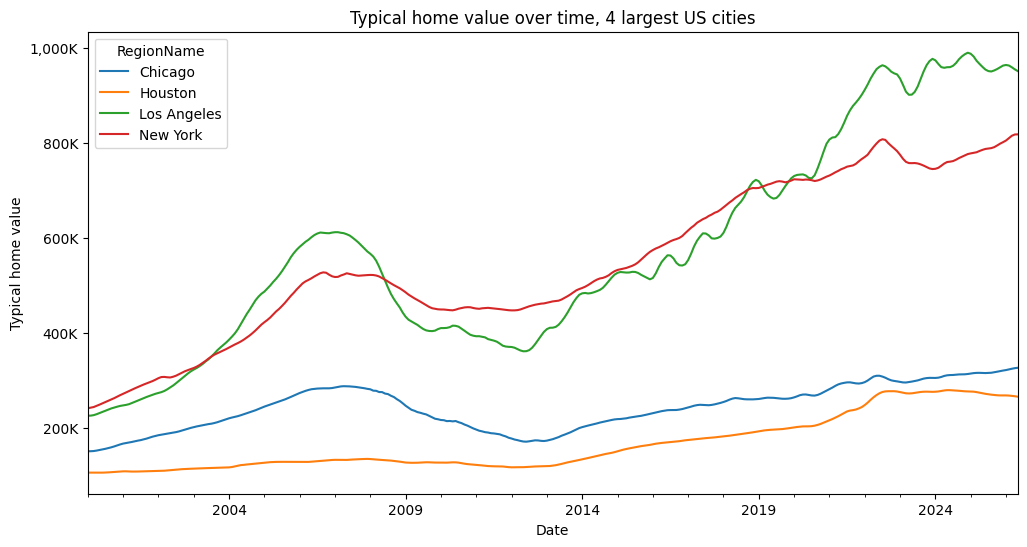

In [64]:
# 1. plot the home values for the 4 largest cities
ax = largest_cities_long.unstack(level=0)['HomeValue'].plot(figsize=(12, 6))

ax.set_title('Typical home value over time, 4 largest US cities')
ax.set_xlabel('Date')
ax.set_ylabel('Typical home value')

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1000:,.0f}K'))

In [67]:
# 2 a. Which city had the highest Typical Home Value at the end of 2008? Which had the least?
end_2008 = largest_cities_long.unstack(level=0)['HomeValue'].loc['2008-12-01']
print(f"Highest: {end_2008.idxmax()} (${end_2008.max():,.0f})")


Highest: New York ($489,304)


In [69]:
# 2 b. How much did the home values change from November 2008 to December 2008 (in dollars)?
city_values = largest_cities_long.unstack(level=0)['HomeValue']

change = city_values.diff().loc['2008-12-01']

change

RegionName
Chicago        -4849.951398
Houston         -900.948023
Los Angeles   -10802.695712
New York       -4076.231966
Name: 2008-12-01 00:00:00, dtype: float64